# 4 空间填充设计

尽管基于模型的方法为构造最优设计提供了一套严谨的理论框架,但该方法仍存在若干实际应用缺陷.基于模型的最优设计依赖相关参数等未知模型参数,且对参数设定偏差不具备鲁棒性.除此之外,各类基于模型的准则计算开销大,数值稳定性较差,大幅提升优化求解的难度与运算成本.因此本章将对基于模型的各类准则做近似处理,并构建以均匀铺满试验区域为目标的填充空间设计.该类设计具备直观几何含义,且可由多种建模思路推导得到,说明其拥有一定程度的模型鲁棒性.

## 4.1 基于聚类的设计

记$D=\{\boldsymbol{x}_{i}\}_{i=1}^{n}$为试验设计,$\mathcal{X}=[0,1]^{p}$为试验区域,考察式(3.1)中的积分均方根误差(IRMSE)准则:

$$\mathrm{IRMSE}(D;\boldsymbol{\theta})=\int_{\mathcal{X}}\sqrt{1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})}\mathrm{d}\boldsymbol{x}$$

式中$\boldsymbol{r}(\boldsymbol{x})=\{R(\boldsymbol{x}-\boldsymbol{x}_{i})\}_{i=1}^{n}$,$\boldsymbol{R}=\{R(\boldsymbol{x}_{i}-\boldsymbol{x}_{j})\}_{i,j=1}^{n}$,$R(\cdot)$代表相关函数.将试验区域划分为$n$个沃罗诺伊区域,满足$\mathcal{X}=V_{1}\cup\cdots\cup V_{n}$,其中

$$V_{i}=\{\boldsymbol{x}\in\mathcal{X},\;\forall j\ne i:\|\boldsymbol{x}-\boldsymbol{x}_{i}\|\le\|\boldsymbol{x}-\boldsymbol{x}_{j}\|\}\tag{4.1}$$

当$i\ne j$时,$V_{i}\cap V_{j}=\varnothing$,因此

$$\mathrm{IRMSE}(D;\boldsymbol{\theta})=\sum_{i=1}^{n}\int_{V_{i}}\sqrt{1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})}\mathrm{d}\boldsymbol{x}$$

后验方差会随试验点数量增多而减小,故$1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})$小于仅采用单个试验点时的方差(洛普基等人,2010),可得不等式

$$1-\boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})\le1-R^{2}(\boldsymbol{x}-\boldsymbol{x}_{i}),\;\forall i\tag{4.2}$$

由此推出

$$\mathrm{IRMSE}(D;\boldsymbol{\theta})\le\sum_{i=1}^{n}\int_{V_{i}}\sqrt{1-R^{2}(\boldsymbol{x}-\boldsymbol{x}_{i})}\mathrm{d}\boldsymbol{x}$$

取各向同性高斯相关函数

$$R(\boldsymbol{\Delta})=\exp\left(-\frac{\|\boldsymbol{\Delta}\|^{2}}{\theta^{2}}\right)\tag{4.3}$$

代入推导可得

$$\begin{align*}\mathrm{IRMSE}(D;\theta)&\le\sum_{i=1}^{n}\int_{V_{i}}\sqrt{1-\exp\left(-2\frac{\|\boldsymbol{x}-\boldsymbol{x}_{i}\|^{2}}{\theta^{2}}\right)}\mathrm{d}\boldsymbol{x}\\&\approx\sum_{i=1}^{n}\int_{V_{i}}\sqrt{1-\left(1-2\frac{\|\boldsymbol{x}-\boldsymbol{x}_{i}\|^{2}}{\theta^{2}}\right)}\mathrm{d}\boldsymbol{x}\\&=\frac{\sqrt{2}}{\theta}\sum_{i=1}^{n}\int_{V_{i}}\|\boldsymbol{x}-\boldsymbol{x}_{i}\|\mathrm{d}\boldsymbol{x}\end{align*}$$

该近似在满足$\max_{i}\max_{\boldsymbol{x}\in V_{i}}\|\boldsymbol{x}-\boldsymbol{x}_{i}\|\ll\theta$时精度较高.通过最小化上述上界,得到最优设计优化模型:

$$\min_{D}\sum_{i=1}^{n}\int_{V_{i}}\|\boldsymbol{x}-\boldsymbol{x}_{i}\|\mathrm{d}\boldsymbol{x}\tag{4.4}$$

上界表达式中相关参数已被分离出去,求解该最优设计不再依赖相关参数.式(4.4)对应的优化问题即为矢量量化问题(格拉夫,卢施吉,2007),可借助聚类算法求解.具体步骤为先在区域$\mathcal{X}$内生成大量均匀采样点$\{\boldsymbol{X}_{j}\}_{j=1}^{N}$,采用蒙特卡罗近似方法(见5.1.2节),原问题可等价转化为

$$\min_{D}\frac{1}{N}\sum_{j=1}^{N}\sum_{i=1}^{n}\delta_{ij}\|\boldsymbol{X}_{j}-\boldsymbol{x}_{i}\|\tag{4.5}$$

式中若$\boldsymbol{X}_{j}\in V_{i}$,则$\delta_{ij}=1$,否则$\delta_{ij}=0$.

同理,式(3.2)的积分均方误差(IMSE)准则可推导出$L_{2}$量化优化问题:

$$\min_{D}\sum_{i=1}^{n}\int_{V_{i}}\|\boldsymbol{x}-\boldsymbol{x}_{i}\|^{2}\mathrm{d}\boldsymbol{x}\tag{4.6}$$

其蒙特卡罗近似形式为

$$\min_{D}\frac{1}{N}\sum_{j=1}^{N}\sum_{i=1}^{n}\delta_{ij}\|\boldsymbol{X}_{j}-\boldsymbol{x}_{i}\|^{2}\tag{4.7}$$

$L_{2}$量化问题在数学上更易求解,劳埃德(1957)与马克斯(1960)最早在通信理论领域提出该模型;它也与最优分层抽样思路(达莱尼乌斯,1950;考克斯,1957),分布代表点理论(弗吕里,1990;方开泰,王,1993)密切相关.式(4.7)是聚类分析中应用最广泛的准则,可通过劳埃德提出的`kmeans`算法求解,该算法交替更新沃罗诺伊区域与各区域均值.而式(4.5)最小化距离和的优化问题起源更早,最早见于设施选址分析与计算几何领域(韦伯,1929);可采用一种与K均值思路相近,通过迭代最小二乘更新中心点的算法求解该问题,即魏斯菲尔德算法.

假设我们需要在二维试验区域$\mathcal{X}=[0,1]^{2}$内布置$n=7$个试验点,可借助自研R语言程序包`SFDesign`(王与约瑟夫,2025c)求解基于聚类的最优设计.依据式(4.4)求得的设计绘制于图4.1,可见样本点能够较好铺满整个区域,但点位会明显向区域中心聚拢,该特性在预测问题中存在弊端.原因在于绝大多数统计模型与机器学习模型对内插预测(在7个点凸包内部做预测)精度较高,而外插预测(在凸包外部做预测)结果可信度较低.莱基维茨与琼斯(2015)提出改进方案:不再选取沃罗诺伊区域的质心作为试验点,而是搭配后文介绍的最大投影准则(MaxPro,约瑟夫等人,2015)作为次级优化指标,从每个沃罗诺伊区域内重新筛选点位,以此改善上述缺陷.

>**图4.1** 含7个样本点的聚类型设计,图中同步给出各沃罗诺伊区域

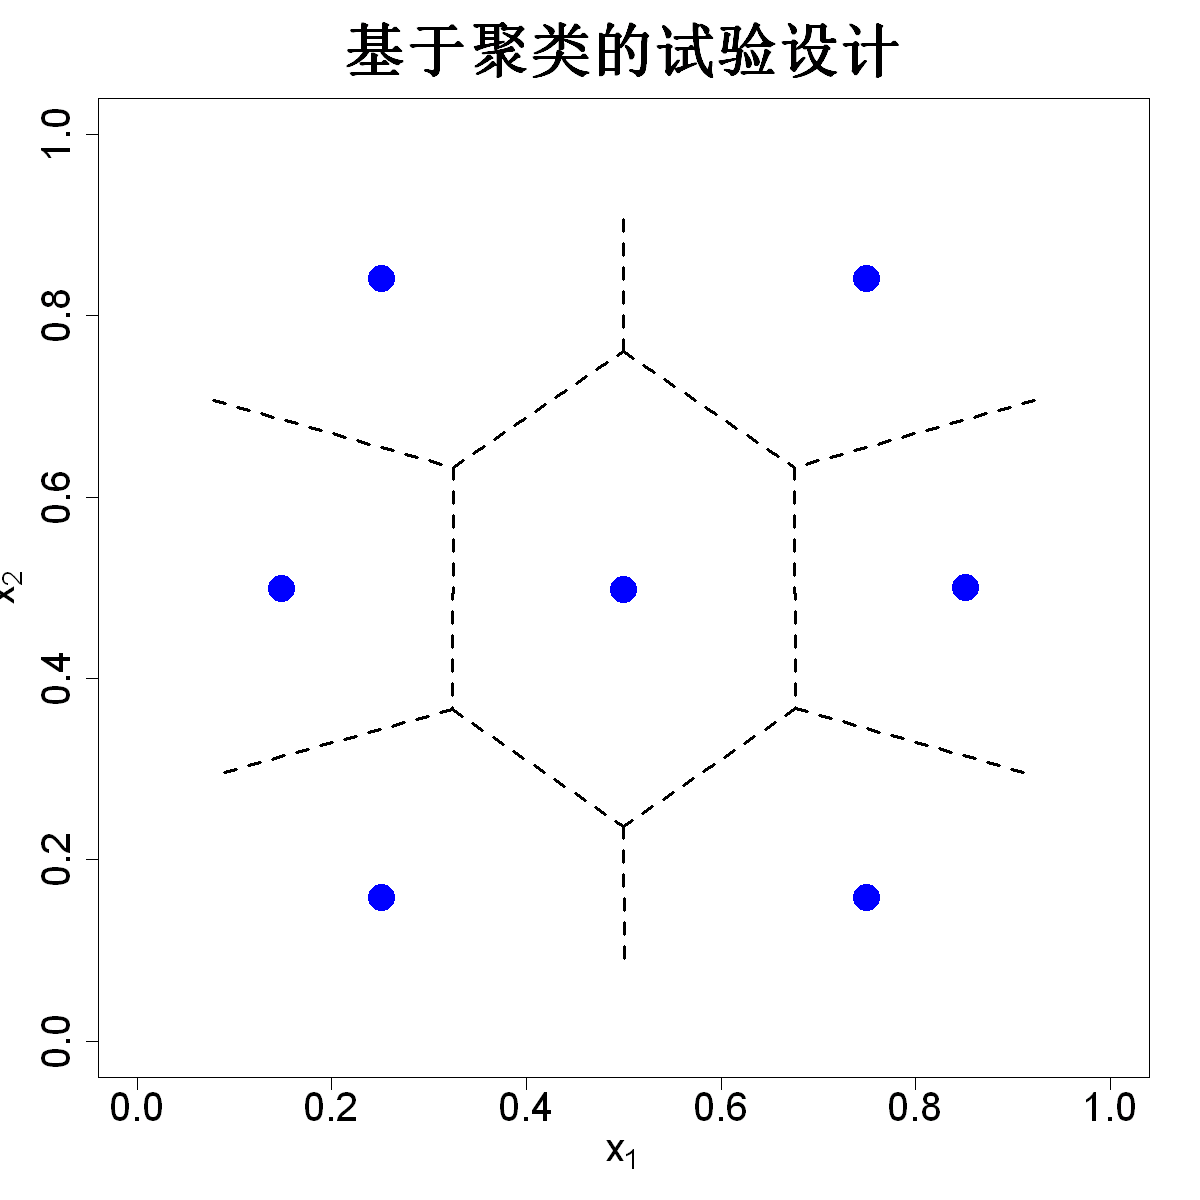

In [2]:
#图4.1

options(repr.plot.width=10,repr.plot.height=10)
p=2;n=7
set.seed(5)
library(mined)
X=Lattice(10000,p)
D2=kmeans(X,centers=n)$centers
library(SFDesign)
D=clustering.design(n,p,D.ini=D2)$design
plot(D,xlim=c(0,1),ylim=c(0,1),main="基于聚类的试验设计",xlab=expression(x[1]),ylab=expression(x[2]),pch=16,col="blue",cex=3,cex.main=3,cex.lab=2,cex.axis=2)
library(deldir)
vor=deldir(D[,1],D[,2])
plot.deldir(vor,add=TRUE,wlines="tess",lwd=3,showpoints=FALSE)